## Setting the initial simulation parameters


In [60]:
# =============================================================================
# API Tutorial of Gamma Oscillations
#
# This notebook accompanies the recorded video walkthrough of generating
# gamma oscillations in the HNN GUI. Each section below corresponds to one
# video and reproduces the same steps using the hnn_core Python API instead
# of the GUI.
#
# This tutorial:
#   1) increases `tstop` from 170 to 300 ms, for better frequency
#      resolution during spectral analysis
#   2) removes dipole smoothing, i.e. we never call dpl.smooth(), so we
#      work with the raw, unsmoothed signal (this preserves high-frequency
#      gamma content that would otherwise be lost)
# =============================================================================

import multiprocessing
import os.path as op

import numpy as np
import matplotlib.pyplot as plt

import hnn_core
from hnn_core import read_params, jones_2009_model, simulate_dipole
from hnn_core.parallel_backends import JoblibBackend
from hnn_core.network import pick_connection
from hnn_core.viz import plot_dipole

# Load the gamma network parameter file. It defines
# connectivity for a network where L2/3 and L5 are NOT connected to each
# other (all cross-layer gbar values are zero)
params_file = op.join(op.dirname(hnn_core.__file__),
                      'param', 'gamma_L5weak_L2weak.json')

# first approach:
params = read_params(params_file)
net = jones_2009_model(params, add_drives_from_params=True)  


'''
# second approach:
net = jones_2009_model(params)

weights_ampa = {
    'L2_pyramidal': 0.0008,
    'L5_pyramidal': 0.0075,
}
synaptic_delays = {
    'L2_pyramidal': 0.1,
    'L5_pyramidal': 1.0,
}
rate_constant = {
    'L2_pyramidal': 140.0,
    'L5_pyramidal': 40.0,
}

net.add_poisson_drive(
    'extpois',
    rate_constant=rate_constant,
    weights_ampa=weights_ampa,
    location='proximal',
    synaptic_delays=synaptic_delays,
    event_seed=1
)
'''

# --- Settings shared by every simulation in this notebook ---
tstop = 300.0            # ms;
tmin = 50.0               # ms; omit the initial transient for spectral analysis
trial_idx = 0             # index of the single trial run in each simulation
scaling_factor = 3000     
freqs = np.arange(20., 100., 1.)   # frequency range (Hz) for spectrogram plots
net.external_drives['extpois']['dynamics']['tstop'] = tstop

n_jobs = multiprocessing.cpu_count()
print(f'Using {n_jobs} CPU cores.')


Using 10 CPU cores.


In [61]:
net.external_drives['extpois']
# print(weights_ampa)
# print(synaptic_delays)

# the last two prints confirm that the drive added with "approach 1" only affect L2 and L5 pyramidal cells, and that the synaptic delays are as expected.

#net.external_drives['extpois']['event_seed'] # event_seed also matches the GUI's value



<External drive 'extpois'
drive class: poisson
target location: proximal
target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
number of drive cells: 270
cell-specific: True
dynamic parameters:
	tstart: 0
	tstop: 300.0
	rate_constant: {'L2_basket': 1, 'L2_pyramidal': 140.0, 'L5_basket': 1, 'L5_pyramidal': 40.0}>

## Run the simulation and visualize the dipole and spectrogram


Joblib will run 1 trial(s) in parallel by distributing trials over 10 jobs.
Loading custom mechanism files from /Users/annacattani/Documents/HNN/hnn-core-gui-master/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...


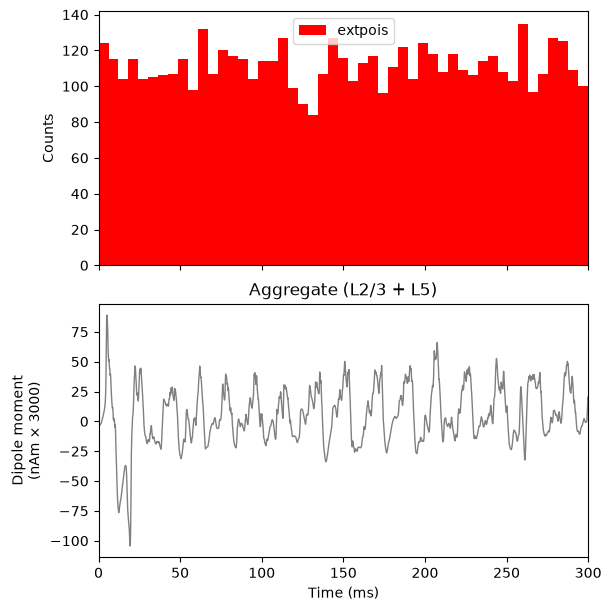

In [62]:
# -----------------------------------------------------------------------
# Run the first simulation and visualize the external input and dipole
# -----------------------------------------------------------------------
with JoblibBackend(n_jobs=n_jobs):
    dpl = simulate_dipole(net, tstop=tstop, n_trials=1)[trial_idx]
dpl.scale(scaling_factor)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6, 6), constrained_layout=True)

# Top panel: external drive spike-time histogram (the single 'extpois' drive)
net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['extpois'], show=False)

# Bottom panel: aggregate dipole waveform
plot_dipole(dpl, ax=axes[1], layer='agg', show=False)

plt.show()


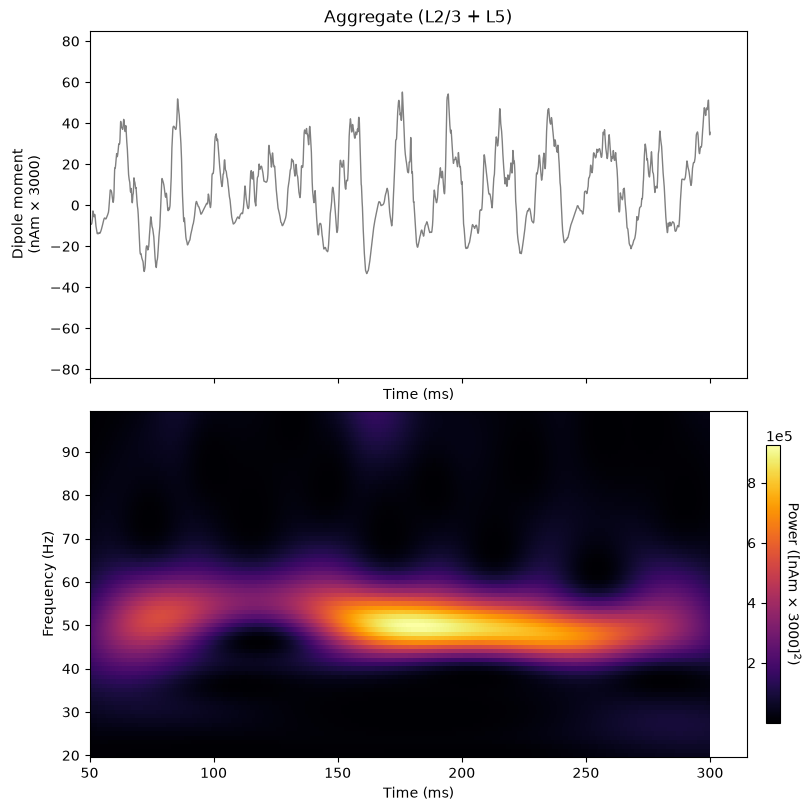

In [ ]:
# -----------------------------------------------------------------------
# Reproduce the GUI's "Dipole Spectrogram" figure: raw dipole waveform on
# top, Morlet time-frequency representation below. We omit the first
# tmin=50 ms transient before any spectral analysis.
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 8), constrained_layout=True)

dpl.plot(tmin=tmin, ax=axes[0], layer='agg', show=False)
axes[0].set_title('Aggregate (L2/3 + L5)')

dpl.plot_tfr_morlet(freqs, n_cycles=7, tmin=tmin, layer='agg', ax=axes[1], show=False)

plt.show()



## Calculating power spectral density and viewing spiking activity


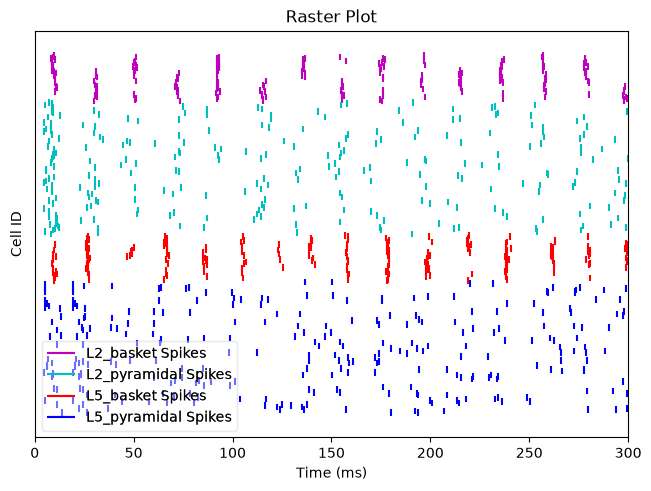

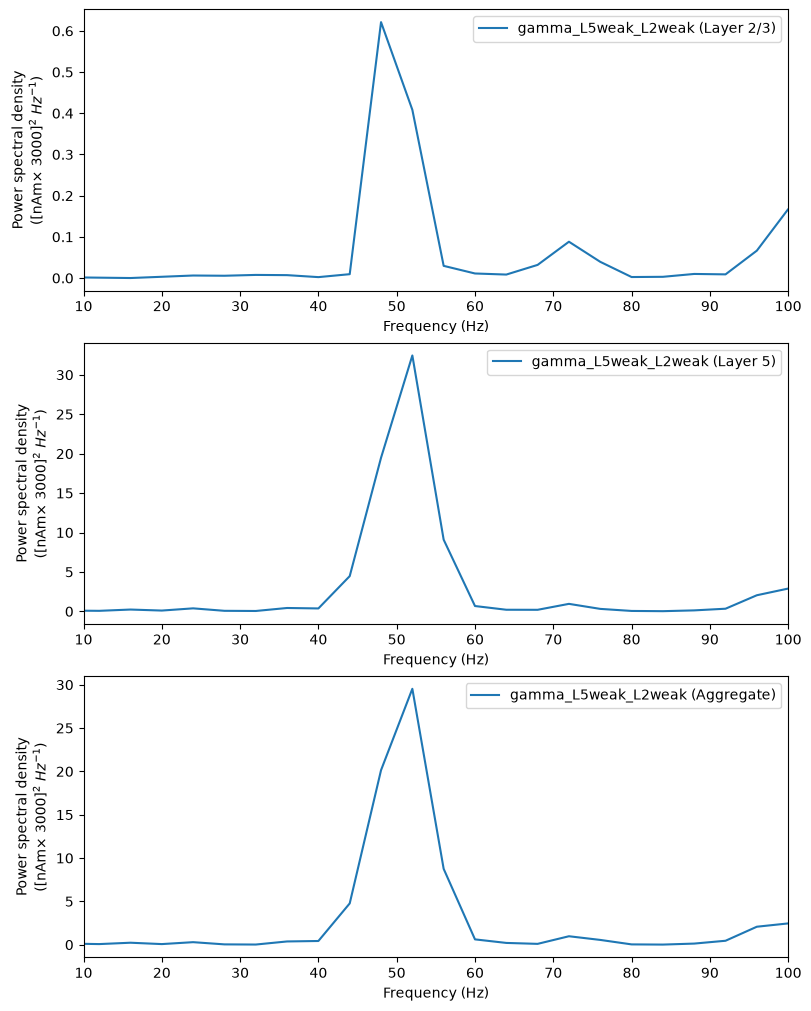

In [ ]:
# -----------------------------------------------------------------------
# Spiking activity and layer-resolved power spectral density (PSD)
#
# The raster shows the PING sequence (pyramidal cells fire, then basket
# cells shortly after, then silence until the next cycle). The PSD is
# plotted separately per layer plus the aggregate: L2/3 and L5 have
# slightly different peak frequencies since the layers are disconnected,
# and L5 has larger PSD amplitude since L5 pyramidal cells contribute more
# strongly to the aggregate dipole.
# -----------------------------------------------------------------------

# function to reproduce the GUI's "PSD Layers" visualization template
def plot_psd_by_layer(dpl_to_plot, sim_name, tmin=50., fmin=10, fmax=100):
    """Plot L2/3, L5, and aggregate PSDs of a dipole in 3 stacked panels.

    This is the API equivalent of the GUI's "PSD Layers" visualization
    template: one subplot per layer, each with its own y-axis scale and a
    legend labeled with `sim_name`.
    """
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)
    layer_labels = [('L2', 'Layer 2/3'), ('L5', 'Layer 5'), ('agg', 'Aggregate')]
    for ax, (layer, layer_label) in zip(axes, layer_labels):
        dpl_to_plot.plot_psd(fmin=fmin, fmax=fmax, tmin=tmin, layer=layer,
                              label=f'{sim_name} ({layer_label})', ax=ax, show=False)
        ax.legend()
    plt.show()
    return fig


_ = net.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = plot_psd_by_layer(dpl, sim_name='gamma_L5weak_L2weak', tmin=tmin)


## Restricting activity to layer 5


Joblib will run 1 trial(s) in parallel by distributing trials over 10 jobs.
Loading custom mechanism files from /Users/annacattani/Documents/HNN/hnn-core-gui-master/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...


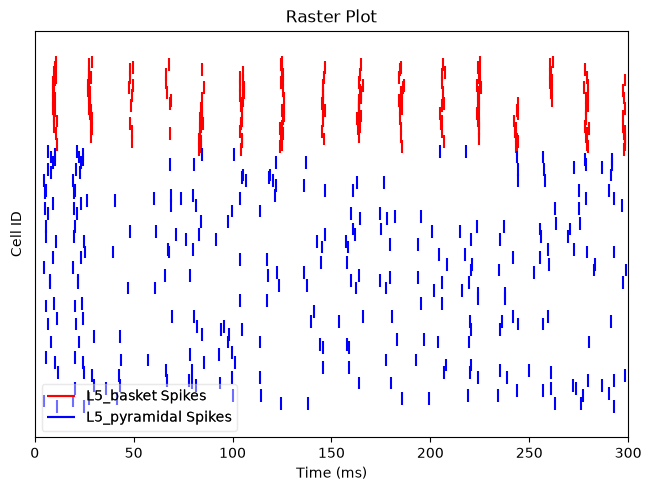

In [13]:
# -----------------------------------------------------------------------
# Restricting activity to layer 5
#
# Build a fresh network and add the Poisson drive to L5_pyramidal only
# (cell types omitted from weights_ampa get zero drive weight). L2/3 stays
# silent for lack of external input while remaining structurally present.
# This net_l5 / dpls_l5 baseline is reused in every section below.
# -----------------------------------------------------------------------
net_l5 = jones_2009_model(params)
net_l5.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)

with JoblibBackend(n_jobs=n_jobs):
    dpls_l5 = simulate_dipole(net_l5, tstop=tstop, n_trials=1)
dpls_l5 = [d.scale(scaling_factor) for d in dpls_l5]

_ = net_l5.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()


## Increasing cell excitability via a weak tonic input


In [ ]:
# -----------------------------------------------------------------------
# Increasing cell excitability via a weak tonic input
#
# Add a tonic bias (i.e., a constant applied current) at 2 nA
# directly to L5 pyramidal cells and compare
# against the net_l5 baseline. Counter-intuitively, even though single-
# cell excitability goes up, the oscillation frequency tends to go down
# slightly: more pyramidal cells fire, recruiting stronger inhibitory
# feedback that takes longer to decay.
# -----------------------------------------------------------------------
net_tonic_weak = jones_2009_model(params)
net_tonic_weak.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)
net_tonic_weak.add_tonic_bias(cell_type='L5_pyramidal', amplitude=2.)

with JoblibBackend(n_jobs=n_jobs):
    dpls_tonic_weak = simulate_dipole(net_tonic_weak, tstop=tstop, n_trials=1)
dpls_tonic_weak = [d.scale(scaling_factor) for d in dpls_tonic_weak]

_ = dpls_tonic_weak[trial_idx].plot(tmin=tmin)
plt.show()

_ = net_tonic_weak.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = plot_psd_by_layer(dpls_tonic_weak[trial_idx],
                       sim_name='gamma_L5weak_only_tonic1', tmin=tmin)


## Increasing tonic input


In [ ]:
# -----------------------------------------------------------------------
# Increasing tonic input further
#
# Push the tonic drive to L5 pyramidal cells up to 6 nA and see whether
# the frequency-lowering trend continues.
# -----------------------------------------------------------------------
net_tonic_strong = jones_2009_model(params)
net_tonic_strong.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)
net_tonic_strong.add_tonic_bias(cell_type='L5_pyramidal', amplitude=6.)

with JoblibBackend(n_jobs=n_jobs):
    dpls_tonic_strong = simulate_dipole(net_tonic_strong, tstop=tstop, n_trials=1)
dpls_tonic_strong = [d.scale(scaling_factor) for d in dpls_tonic_strong]

_ = net_tonic_strong.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = dpls_tonic_strong[trial_idx].plot(tmin=tmin)
plt.show()

# Compare against the previous cell's PSDs to see the effect of increasing
# the tonic drive from 2 to 6 nA.
_ = plot_psd_by_layer(dpls_tonic_strong[trial_idx],
                       sim_name='gamma_L5weak_only_tonic2', tmin=tmin)


## Weakening the excitatory connections


In [ ]:
# -----------------------------------------------------------------------
# Weakening the excitatory L5 Pyramidal -> L5 Basket connection
#
# Change connectivity: reduce the excitatory (AMPA)
# synaptic weight from L5 pyramidal cells onto L5 basket cells to
# one-tenth of its original value, keeping the 6 nA tonic drive from the
# previous section. Because excitation
# onto basket cells is weaker, they take longer to reach threshold,
# delaying inhibitory feedback and slowing the oscillation.
# -----------------------------------------------------------------------
net_weak_conn = jones_2009_model(params)
net_weak_conn.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)
net_weak_conn.add_tonic_bias(cell_type='L5_pyramidal', amplitude=6.)

conn_indices = pick_connection(net_weak_conn, src_gids='L5_pyramidal',
                                target_gids='L5_basket', receptor='ampa')
for idx in conn_indices:
    print('original weight:', net_weak_conn.connectivity[idx]['weight'])
    net_weak_conn.connectivity[idx]['weight'] *= 0.1
    print('new weight:', net_weak_conn.connectivity[idx]['weight'])

with JoblibBackend(n_jobs=n_jobs):
    dpls_weak_conn = simulate_dipole(net_weak_conn, tstop=tstop, n_trials=1)
dpls_weak_conn = [d.scale(scaling_factor) for d in dpls_weak_conn]

_ = net_weak_conn.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

_ = dpls_weak_conn[trial_idx].plot(tmin=tmin)
plt.show()

_ = plot_psd_by_layer(dpls_weak_conn[trial_idx],
                       sim_name='gamma_L5weak_only_tonic3', tmin=tmin)


## Removing basket cell self-inhibition


In [ ]:
# -----------------------------------------------------------------------
# Removing basket-cell self-inhibition
#
# Back to the unmodified net_l5 configuration (no tonic drive, original
# connectivity): set the L5 Basket -> L5 Basket (GABA-A) synaptic weight
# to zero, so basket cells no longer inhibit one another. Without this
# self-inhibition, interneurons lose their synchrony and fire more
# irregularly, so inhibition arriving at pyramidal cells is smeared out in
# time rather than delivered as one coordinated pulse. The gamma rhythm
# persists but becomes less coherent.
# -----------------------------------------------------------------------
net_no_bb = jones_2009_model(params)
net_no_bb.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)

conn_indices = pick_connection(net_no_bb, src_gids='L5_basket',
                                target_gids='L5_basket', receptor='gabaa')
for idx in conn_indices:
    print('original weight:', net_no_bb.connectivity[idx]['weight'])
    net_no_bb.connectivity[idx]['weight'] = 0.

with JoblibBackend(n_jobs=n_jobs):
    dpls_no_bb = simulate_dipole(net_no_bb, tstop=tstop, n_trials=1)
dpls_no_bb = [d.scale(scaling_factor) for d in dpls_no_bb]

_ = net_no_bb.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(6, 6),
                          constrained_layout=True)
dpls_no_bb[trial_idx].plot(tmin=tmin, ax=axes[0], show=False)
dpls_no_bb[trial_idx].plot_tfr_morlet(freqs, n_cycles=7, tmin=tmin, ax=axes[1], show=False)
axes[1].set_xlim(tmin, tstop)
plt.show()

_ = plot_psd_by_layer(dpls_no_bb[trial_idx],
                       sim_name='gamma_L5weak_only_noinhibition', tmin=tmin)


## Reducing the GABAA decay time


In [ ]:
# -----------------------------------------------------------------------
# Reducing the GABA-A decay time constant
#
# Back to the unmodified net_l5 configuration once more: shorten the
# GABA-A decay time constant (tau2) of synapses onto L5 pyramidal cells
# from the default 5 ms to 2 ms. Faster-decaying inhibition lets
# pyramidal cells recover and fire again sooner, which increases
# the oscillation frequency.
# -----------------------------------------------------------------------
net_gabaa = jones_2009_model(params)
net_gabaa.add_poisson_drive(
    'poisson', rate_constant={'L5_pyramidal': 40.0},
    weights_ampa={'L5_pyramidal': 0.0075}, location='proximal',
    synaptic_delays={'L5_pyramidal': 1.0}, event_seed=1349)

print('original GABA-A tau2:',
      net_gabaa.cell_types['L5_pyramidal']['cell_object'].synapses['gabaa']['tau2'], 'ms')
net_gabaa.cell_types['L5_pyramidal']['cell_object'].synapses['gabaa']['tau2'] = 2

with JoblibBackend(n_jobs=n_jobs):
    dpls_gabaa = simulate_dipole(net_gabaa, tstop=tstop, n_trials=1)
dpls_gabaa = [d.scale(scaling_factor) for d in dpls_gabaa]

_ = net_gabaa.cell_response.plot_spikes_raster(trial_idx=trial_idx)
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(6, 6),
                          constrained_layout=True)
dpls_gabaa[trial_idx].plot(tmin=tmin, ax=axes[0], show=False)
dpls_gabaa[trial_idx].plot_tfr_morlet(freqs, n_cycles=7, tmin=tmin, ax=axes[1], show=False)
axes[1].set_xlim(tmin, tstop)
plt.show()

_ = plot_psd_by_layer(dpls_gabaa[trial_idx],
                       sim_name='gamma_L5weak_only_shorter_decay_gabaa', tmin=tmin)


### Strong PING still missing